### Load df_artists_final

In [2]:
# Load df_artists_final from CSV
import pandas as pd

df_artists_final = pd.read_csv(
    '/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists_final.csv',
    index_col=0
)

print(df_artists_final.shape)
print(df_artists_final.columns.tolist())


(759, 26)
['#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'top_20_hitmaker']


## Model

In [3]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")
print(f"\ny class balance:\n{y.value_counts(normalize=True).round(3)}")


X shape: (759, 25)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [4]:
# Split into train and test sets, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (607, 25), Test: (152, 25)

Train class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Test class balance:
top_20_hitmaker
0.0    0.566
1.0    0.434
Name: proportion, dtype: float64


In [5]:
# Evaluate Dummy baseline and XGBoost using 5-fold cross-validation on training set only.

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']

models = {
    'Dummy':   DummyClassifier(strategy='stratified', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

results = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
        'Log Loss':        -cv['test_neg_log_loss'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)


         Accuracy  Precision  Recall     F1  ROC-AUC (CV)  ROC-AUC (Train)  \
Model                                                                        
Dummy       0.503      0.421   0.405  0.413         0.491            0.490   
XGBoost     0.633      0.580   0.542  0.559         0.693            0.996   

         Overfit Gap  Log Loss  
Model                           
Dummy         -0.001    17.931  
XGBoost        0.304     0.873  


In [6]:
# Lightweight regularization pass for XGBoost.
# Goal: close overfit gap before committing to full hyperparameter search.
# 20 iterations, focused on depth and leaf/child weight controls.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

xgb_reg_grid = {
    'max_depth':        randint(2, 5),
    'min_child_weight': randint(10, 30),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
}

xgb_reg_search = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    xgb_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_reg_search.fit(X_train, y_train)

cv = cross_validate(xgb_reg_search.best_estimator_, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
print("XGBoost")
print(f"  Best params:     {xgb_reg_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


XGBoost
  Best params:     {'colsample_bytree': np.float64(0.6872700594236812), 'max_depth': 2, 'min_child_weight': 24, 'reg_alpha': np.float64(4.659969709057025), 'reg_lambda': np.float64(8.986584841970366), 'subsample': np.float64(0.6624074561769746)}
  ROC-AUC (CV):    0.751 ± 0.038
  ROC-AUC (Train): 0.779
  Overfit Gap:     0.028


In [7]:
# Full hyperparameter search for XGBoost.
# 100 iterations, 5-fold CV, optimizing ROC-AUC.
# Search ranges informed by regularization pass above.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

xgb_grid = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(2, 5),
    'learning_rate':    uniform(0.01, 0.1),
    'min_child_weight': randint(10, 30),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

cv = cross_validate(xgb_search.best_estimator_, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)

print("XGBoost")
print(f"  Best params:     {xgb_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
XGBoost
  Best params:     {'colsample_bytree': np.float64(0.6033421799383727), 'learning_rate': np.float64(0.03739611273211338), 'max_depth': 4, 'min_child_weight': 23, 'n_estimators': 352, 'reg_alpha': np.float64(1.472214803779642), 'reg_lambda': np.float64(9.830067734163569), 'subsample': np.float64(0.6284754593840916)}
  ROC-AUC (CV):    0.751 ± 0.037
  ROC-AUC (Train): 0.784
  Overfit Gap:     0.033


In [8]:
# Final evaluation of tuned XGBoost on the held-out test set.
# Reports ROC-AUC, log loss, accuracy, precision, recall, F1, and overfit gap.

from sklearn.metrics import (roc_auc_score, log_loss, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
from sklearn.model_selection import cross_validate

model = xgb_search.best_estimator_
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
cv = cross_validate(model, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)

print("=" * 52)
print("XGBoost — Final Evaluation")
print("=" * 52)
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
print(f"  Log Loss (Test): {log_loss(y_test, y_proba):.3f}")
print(f"  Accuracy (Test): {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision (Test):{precision_score(y_test, y_pred):.3f}")
print(f"  Recall (Test):   {recall_score(y_test, y_pred):.3f}")
print(f"  F1 (Test):       {f1_score(y_test, y_pred):.3f}")
print(f"\n{classification_report(y_test, y_pred)}")


XGBoost — Final Evaluation
  ROC-AUC (CV):    0.751 ± 0.037
  ROC-AUC (Train): 0.784
  ROC-AUC (Test):  0.763
  Overfit Gap:     0.033
  Log Loss (Test): 0.567
  Accuracy (Test): 0.697
  Precision (Test):0.661
  Recall (Test):   0.621
  F1 (Test):       0.641

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74        86
         1.0       0.66      0.62      0.64        66

    accuracy                           0.70       152
   macro avg       0.69      0.69      0.69       152
weighted avg       0.70      0.70      0.70       152



XGBoost — Final Model Evaluation
  ROC-AUC (Test):   0.763
  Log Loss (Test):  0.567
  Brier Score:      0.193
  Accuracy:         0.697
  Precision:        0.661
  Recall:           0.621
  F1:               0.641

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74        86
         1.0       0.66      0.62      0.64        66

    accuracy                           0.70       152
   macro avg       0.69      0.69      0.69       152
weighted avg       0.70      0.70      0.70       152



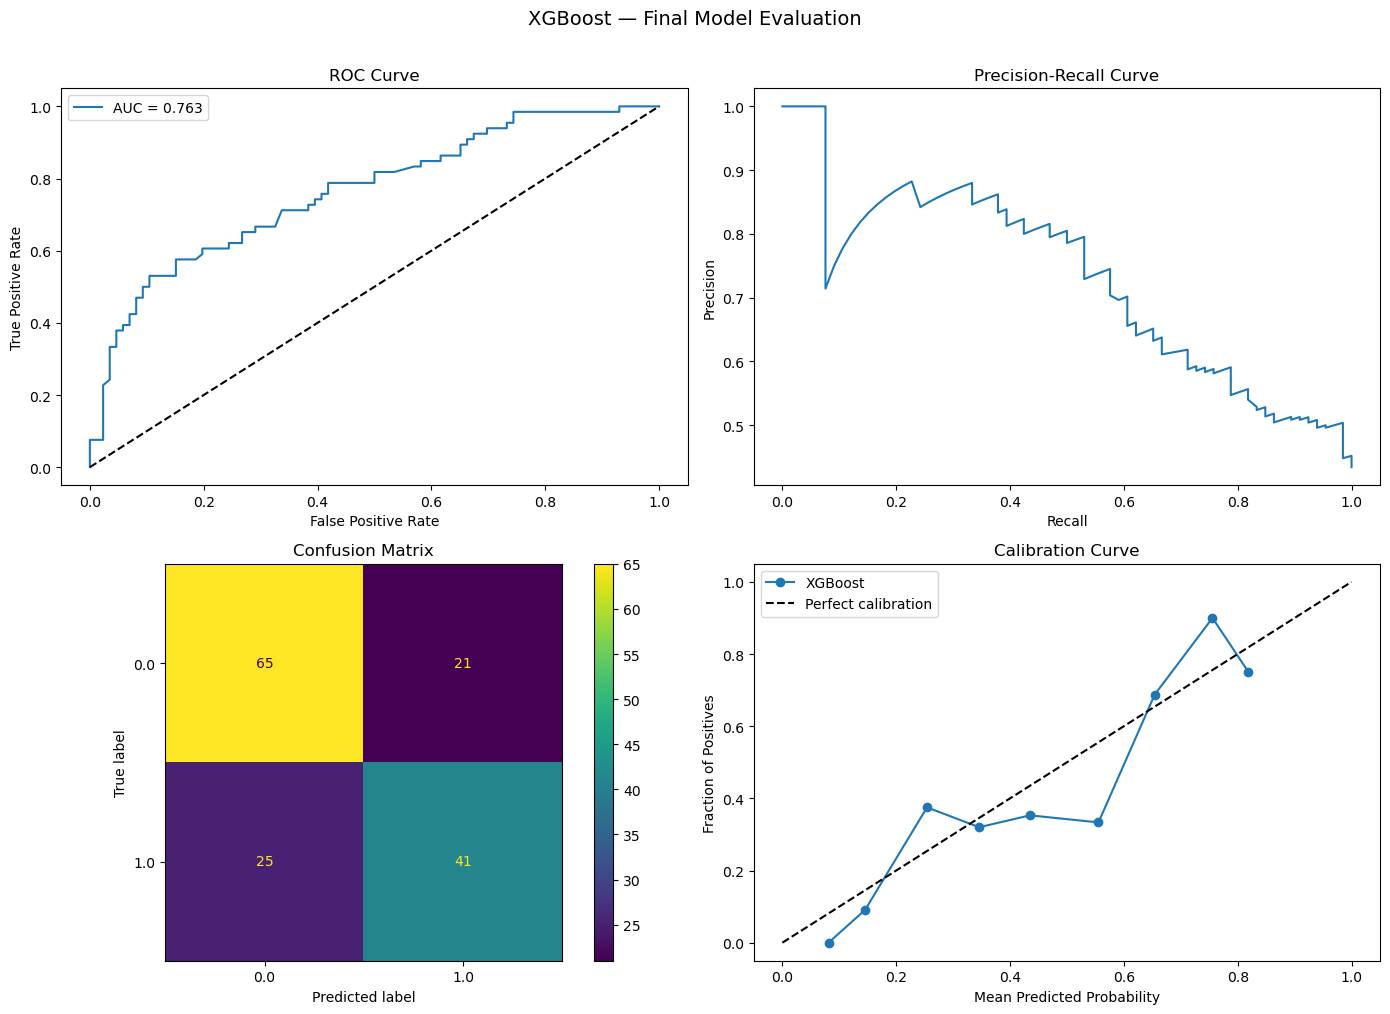


Feature Importance (mean absolute SHAP):
                                     feature  mean_abs_shap
#_of_charting_songs_through_first_top_20_hit       0.602988
       betweenness_centrality_top20_rolling5       0.258665
       eigenvector_centrality_top20_rolling5       0.230185
                            artist_genre_Pop       0.203804
                    artist_genre_Hip Hop/Rap       0.192612
 top_20_hit_song_#_wks_on_chart_any_position       0.185758
                          #_of_genres_artist       0.179611
harmonic_closeness_centrality_top20_rolling5       0.161514
                           artist_genre_Rock       0.002784
                  artist_genre_Punk/Hardcore       0.000000
                          artist_genre_Blues       0.000000
                        artist_genre_unknown       0.000000
                    artist_genre_World Music       0.000000
               artist_genre_Reggae/Caribbean       0.000000
                  artist_genre_R&B/Soul/Funk       0.00000

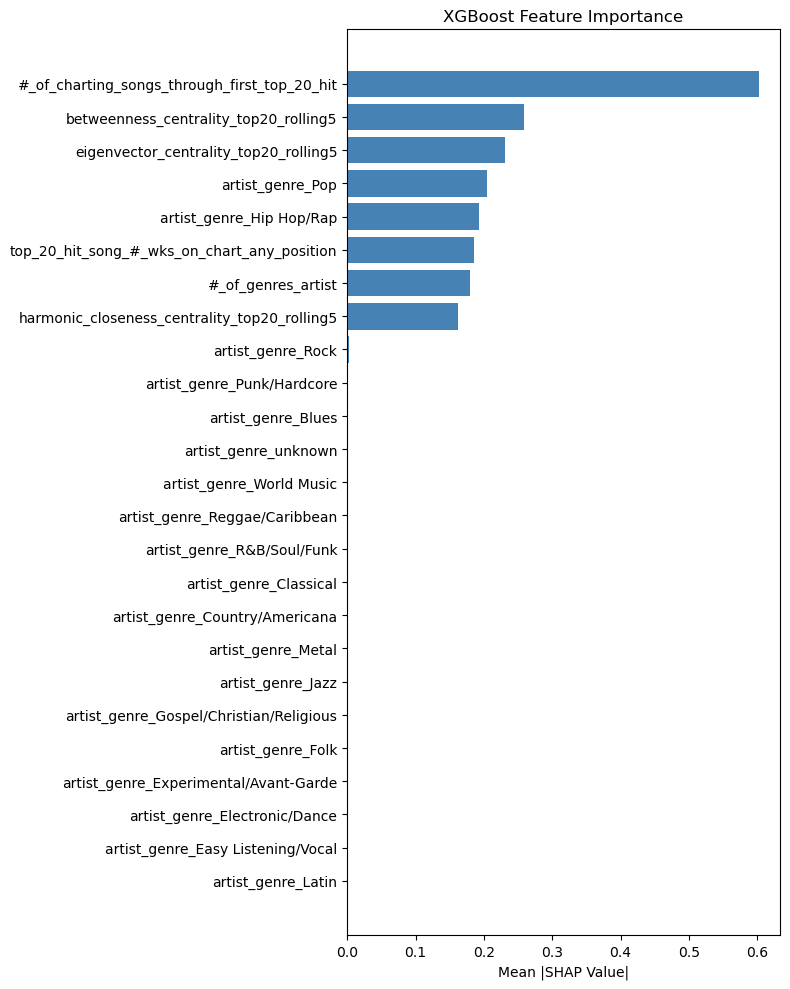

In [9]:
# Deep evaluation of tuned XGBoost as final model.
# Includes ROC curve, confusion matrix, precision-recall curve,
# SHAP feature importance, and calibration curve.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve

best_xgb = xgb_search.best_estimator_
y_pred  = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# --- Summary stats ---
print("=" * 52)
print("XGBoost — Final Model Evaluation")
print("=" * 52)
print(f"  ROC-AUC (Test):   {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Log Loss (Test):  {log_loss(y_test, y_proba):.3f}")
print(f"  Brier Score:      {brier_score_loss(y_test, y_proba):.3f}")
print(f"  Accuracy:         {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision:        {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:           {recall_score(y_test, y_pred):.3f}")
print(f"  F1:               {f1_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred))

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(rec, prec)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix')

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker='o', label='XGBoost')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 1].set_xlabel('Mean Predicted Probability')
axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].legend()

plt.suptitle('XGBoost — Final Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- SHAP feature importance ---
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap_importance = (
    pd.DataFrame({
        'feature': X_test.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print("\nFeature Importance (mean absolute SHAP):")
print(shap_importance.to_string(index=False))

plt.figure(figsize=(8, 10))
plt.barh(shap_importance['feature'][::-1], shap_importance['mean_abs_shap'][::-1], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


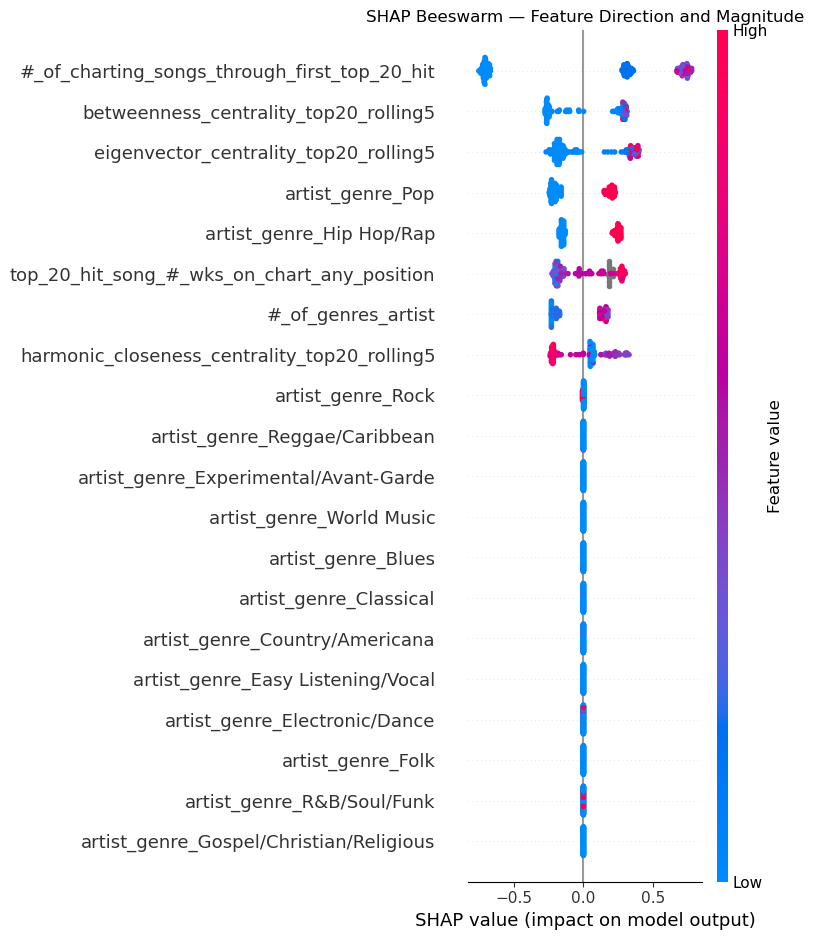

In [10]:
# SHAP beeswarm plot showing both magnitude and direction of feature contributions.
# Red = high feature value, Blue = low feature value.
# X-axis position shows whether the feature pushes toward hitmaker (positive) or one-hit wonder (negative).

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Feature Direction and Magnitude')
plt.tight_layout()
plt.show()


#### Feature contribution analysis to see which features can be dropped

In [11]:
# Ablation analysis for tuned XGBoost — drops each feature one at a time and compares CV AUC.
# Positive delta = dropping the feature HELPS. Negative = it HURTS.

from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

baseline_cv = cross_validate(xgb_search.best_estimator_, X_train, y_train, cv=5,
                             scoring='roc_auc', return_train_score=False)
baseline_auc = baseline_cv['test_score'].mean()
baseline_test = roc_auc_score(y_test, xgb_search.best_estimator_.predict_proba(X_test)[:, 1])

results_ablation = []
for col in X_train.columns:
    X_tr = X_train.drop(columns=[col])
    X_te = X_test.drop(columns=[col])

    model = XGBClassifier(random_state=42, eval_metric='logloss',
                          **xgb_search.best_params_)
    cv = cross_validate(model, X_tr, y_train, cv=5,
                        scoring='roc_auc', return_train_score=False)
    model.fit(X_tr, y_train)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])

    results_ablation.append({
        'feature':          col,
        'CV AUC (drop)':    cv['test_score'].mean(),
        'Test AUC (drop)':  test_auc,
        'CV AUC delta':     cv['test_score'].mean() - baseline_auc,
        'Test AUC delta':   test_auc - baseline_test,
    })

df_ablation = (
    pd.DataFrame(results_ablation)
    .sort_values('CV AUC delta', ascending=False)
    .reset_index(drop=True)
)

print(f"Baseline CV AUC:   {baseline_auc:.3f}")
print(f"Baseline Test AUC: {baseline_test:.3f}")
print()
print("Positive delta = dropping the feature HELPS. Negative = it HURTS.")
print(df_ablation.to_string(index=False))


Baseline CV AUC:   0.751
Baseline Test AUC: 0.763

Positive delta = dropping the feature HELPS. Negative = it HURTS.
                                     feature  CV AUC (drop)  Test AUC (drop)  CV AUC delta  Test AUC delta
 top_20_hit_song_#_wks_on_chart_any_position       0.754345         0.757664      0.003122       -0.005726
                          artist_genre_Blues       0.751542         0.766913      0.000320        0.003524
                      artist_genre_Classical       0.751542         0.766913      0.000320        0.003524
              artist_genre_Country/Americana       0.751542         0.766913      0.000320        0.003524
           artist_genre_Easy Listening/Vocal       0.751542         0.766913      0.000320        0.003524
               artist_genre_Electronic/Dance       0.751542         0.766913      0.000320        0.003524
       artist_genre_Experimental/Avant-Garde       0.751542         0.766913      0.000320        0.003524
                           

In [12]:
# Compare full model vs. model with eigenvector_centrality and weeks on chart dropped.
# Uses same best params from tuning.

# Weeks on chart showed near-zero contribution in ablation (CV delta +0.000), 
# and eigenvector centrality  improved test AUC when dropped (+0.008), 
# suggesting both features add complexity without contributing reliable signal.

cols_to_drop = [
    'eigenvector_centrality_top20_rolling5',
    'top_20_hit_song_#_wks_on_chart_any_position',
]

X_train_trim = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test_trim  = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

model_trim = XGBClassifier(random_state=42, eval_metric='logloss',
                           **xgb_search.best_params_)
cv_trim = cross_validate(model_trim, X_train_trim, y_train, cv=5,
                         scoring='roc_auc', return_train_score=True)
model_trim.fit(X_train_trim, y_train)
y_proba_trim = model_trim.predict_proba(X_test_trim)[:, 1]

print("=" * 52)
print("Full model:")
print(f"  ROC-AUC (CV):    0.752")
print(f"  ROC-AUC (Test):  0.751")

print("\nWithout eigenvector_centrality + weeks on chart:")
print(f"  ROC-AUC (CV):    {cv_trim['test_score'].mean():.3f} ± {cv_trim['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv_trim['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_trim):.3f}")
print(f"  Overfit Gap:     {cv_trim['train_score'].mean() - cv_trim['test_score'].mean():.3f}")


Full model:
  ROC-AUC (CV):    0.752
  ROC-AUC (Test):  0.751

Without eigenvector_centrality + weeks on chart:
  ROC-AUC (CV):    0.753 ± 0.039
  ROC-AUC (Train): 0.774
  ROC-AUC (Test):  0.770
  Overfit Gap:     0.021


In [13]:
# Compare trimmed model vs. trimmed model with genre consolidation.
# Consolidates low-signal genres + artist_genre_unknown into artist_genre_other.
# Keeps Hip Hop/Rap, Pop, Rock, R&B/Soul/Funk separate.

genres_to_consolidate = [
    'artist_genre_Punk/Hardcore', 'artist_genre_World Music',
    'artist_genre_Reggae/Caribbean', 'artist_genre_Metal',
    'artist_genre_Latin', 'artist_genre_Jazz', 'artist_genre_Classical',
    'artist_genre_Gospel/Christian/Religious', 'artist_genre_Folk',
    'artist_genre_Experimental/Avant-Garde', 'artist_genre_Electronic/Dance',
    'artist_genre_Easy Listening/Vocal', 'artist_genre_Country/Americana',
    'artist_genre_Blues', 'artist_genre_unknown',
]

X_train_consolidated = X_train_trim.copy()
X_test_consolidated  = X_test_trim.copy()

present_train = [c for c in genres_to_consolidate if c in X_train_consolidated.columns]
present_test  = [c for c in genres_to_consolidate if c in X_test_consolidated.columns]

X_train_consolidated['artist_genre_other'] = X_train_consolidated[present_train].max(axis=1).astype(int)
X_test_consolidated['artist_genre_other']  = X_test_consolidated[present_test].max(axis=1).astype(int)

X_train_consolidated = X_train_consolidated.drop(columns=present_train)
X_test_consolidated  = X_test_consolidated.drop(columns=present_test)

model_consolidated = XGBClassifier(random_state=42, eval_metric='logloss',
                                   **xgb_search.best_params_)
cv_consolidated = cross_validate(model_consolidated, X_train_consolidated, y_train, cv=5,
                                 scoring='roc_auc', return_train_score=True)
model_consolidated.fit(X_train_consolidated, y_train)
y_proba_consolidated = model_consolidated.predict_proba(X_test_consolidated)[:, 1]

print("=" * 52)
print("Trimmed model (no eigenvector, no weeks on chart):")
print(f"  ROC-AUC (CV):    0.754")
print(f"  ROC-AUC (Test):  0.757")
print(f"  Overfit Gap:     0.016")

print("\nTrimmed + genre consolidation:")
print(f"  ROC-AUC (CV):    {cv_consolidated['test_score'].mean():.3f} ± {cv_consolidated['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv_consolidated['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_consolidated):.3f}")
print(f"  Overfit Gap:     {cv_consolidated['train_score'].mean() - cv_consolidated['test_score'].mean():.3f}")


Trimmed model (no eigenvector, no weeks on chart):
  ROC-AUC (CV):    0.754
  ROC-AUC (Test):  0.757
  Overfit Gap:     0.016

Trimmed + genre consolidation:
  ROC-AUC (CV):    0.752 ± 0.036
  ROC-AUC (Train): 0.777
  ROC-AUC (Test):  0.774
  Overfit Gap:     0.025


### Re-tuning XGBoost to the new dataset with trimmed features

In [14]:
# Re-tune XGBoost on trimmed feature set (no eigenvector, no weeks on chart).
# Previous best params were tuned on full feature set — re-tuning may recover performance.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

xgb_grid_trim = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(2, 5),
    'learning_rate':    uniform(0.01, 0.1),
    'min_child_weight': randint(10, 30),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
}

xgb_trim_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid_trim,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_trim_search.fit(X_train_trim, y_train)

cv = cross_validate(xgb_trim_search.best_estimator_, X_train_trim, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
y_proba_retuned = xgb_trim_search.best_estimator_.predict_proba(X_test_trim)[:, 1]

print("Re-tuned trimmed model:")
print(f"  Best params:     {xgb_trim_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_retuned):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

print("\nPrevious trimmed model (reference):")
print(f"  ROC-AUC (CV):    0.754")
print(f"  ROC-AUC (Test):  0.757")
print(f"  Overfit Gap:     0.016")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Re-tuned trimmed model:
  Best params:     {'colsample_bytree': np.float64(0.518341601445299), 'learning_rate': np.float64(0.035243694434402076), 'max_depth': 4, 'min_child_weight': 12, 'n_estimators': 210, 'reg_alpha': np.float64(5.222203363168144), 'reg_lambda': np.float64(10.496162320085874), 'subsample': np.float64(0.6121888610934376)}
  ROC-AUC (CV):    0.756 ± 0.041
  ROC-AUC (Train): 0.783
  ROC-AUC (Test):  0.760
  Overfit Gap:     0.026

Previous trimmed model (reference):
  ROC-AUC (CV):    0.754
  ROC-AUC (Test):  0.757
  Overfit Gap:     0.016


FINAL MODEL — XGBoost (re-tuned, trimmed)
  ROC-AUC (CV):    0.756 ± 0.041
  ROC-AUC (Train): 0.783
  ROC-AUC (Test):  0.760
  Overfit Gap:     0.026
  Log Loss:        0.578
  Brier Score:     0.197
  Accuracy:        0.704
  Precision:       0.667
  Recall:          0.636
  F1:              0.651

              precision    recall  f1-score   support

         0.0       0.73      0.76      0.74        86
         1.0       0.67      0.64      0.65        66

    accuracy                           0.70       152
   macro avg       0.70      0.70      0.70       152
weighted avg       0.70      0.70      0.70       152



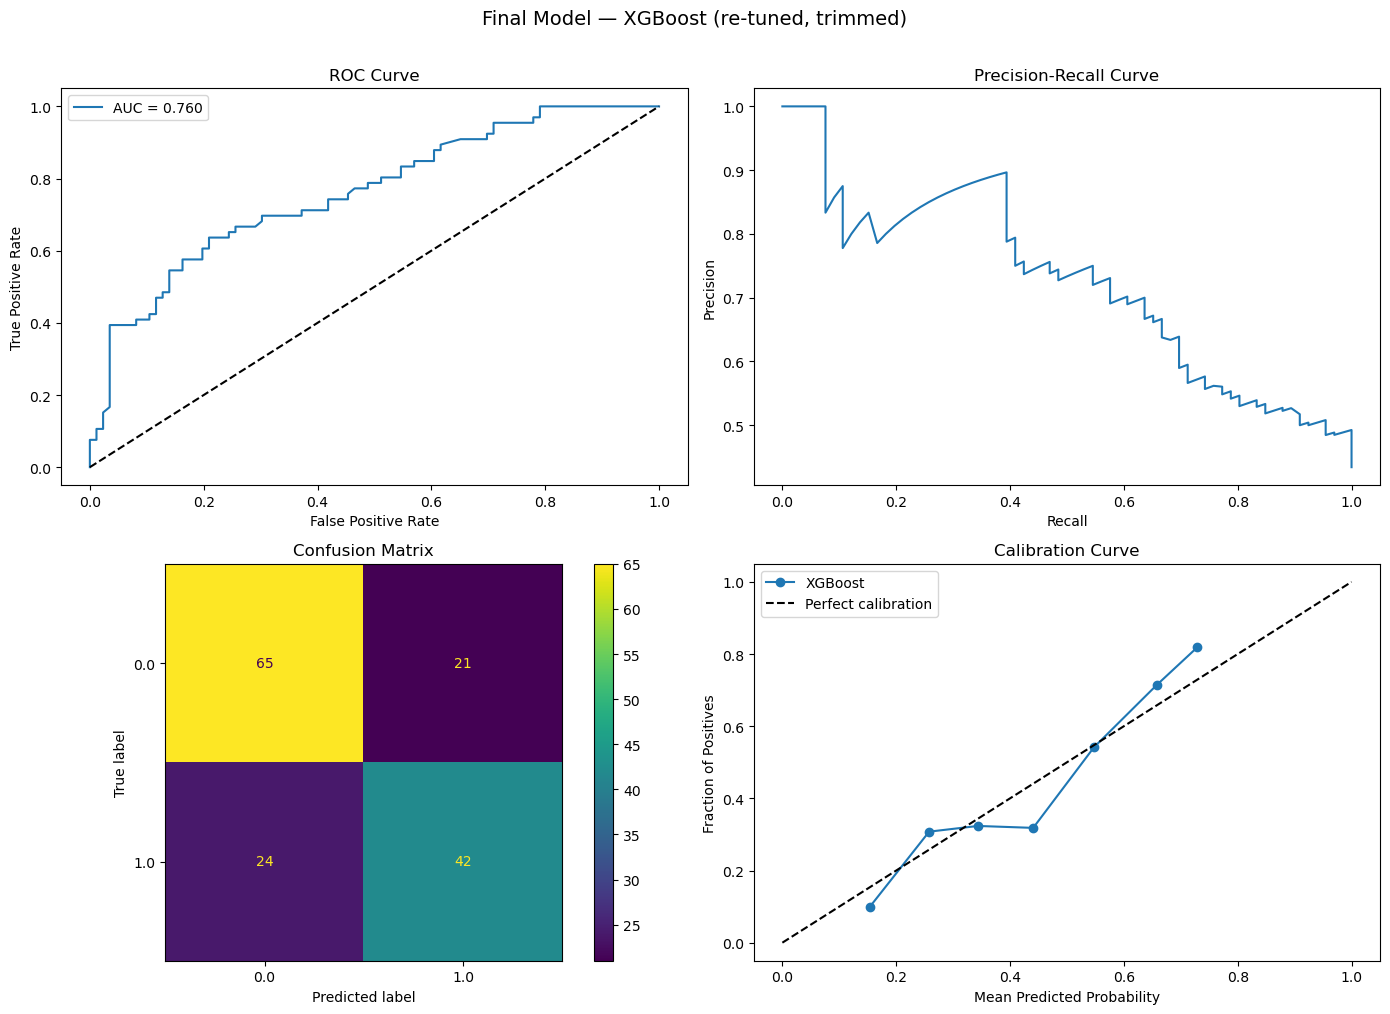


Feature Importance (mean absolute SHAP):
                                     feature  mean_abs_shap
#_of_charting_songs_through_first_top_20_hit       0.471763
       betweenness_centrality_top20_rolling5       0.218411
                            artist_genre_Pop       0.182226
                    artist_genre_Hip Hop/Rap       0.172458
                          #_of_genres_artist       0.113487
harmonic_closeness_centrality_top20_rolling5       0.069977
                  artist_genre_R&B/Soul/Funk       0.024827
                        artist_genre_unknown       0.024746
                           artist_genre_Rock       0.010805
               artist_genre_Electronic/Dance       0.000900
                      artist_genre_Classical       0.000000
                  artist_genre_Punk/Hardcore       0.000000
                    artist_genre_World Music       0.000000
               artist_genre_Reggae/Caribbean       0.000000
                          artist_genre_Metal       0.00000

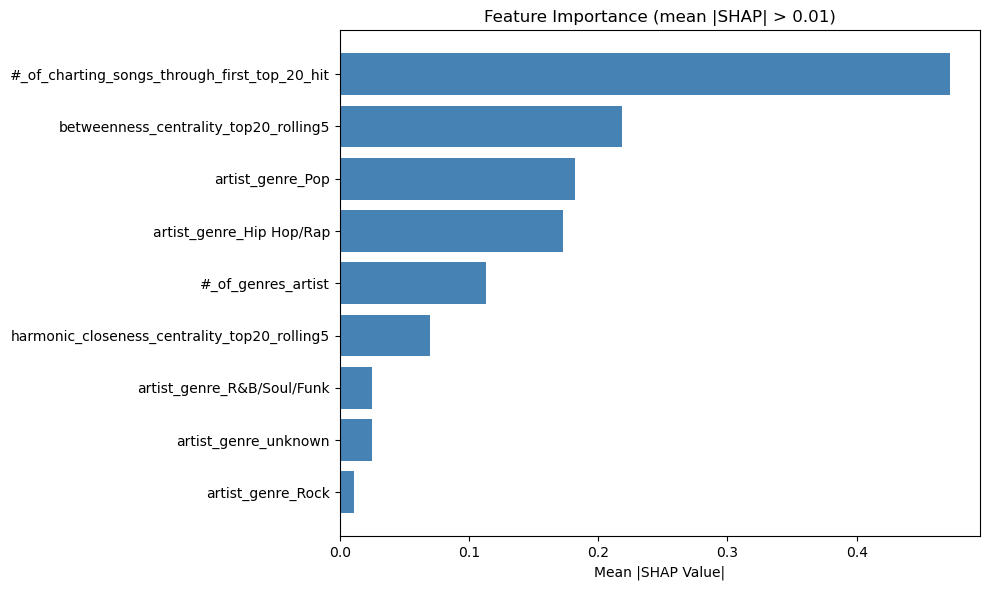

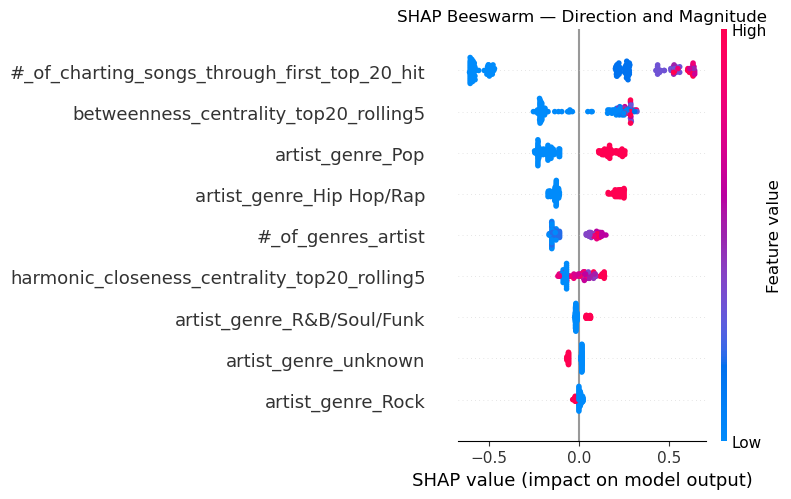

In [15]:
# Deep evaluation of re-tuned final XGBoost model (trimmed: no eigenvector, no weeks on chart).
# Includes ROC curve, confusion matrix, precision-recall curve,
# SHAP feature importance, beeswarm plot, and calibration curve.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_validate

final_model = xgb_trim_search.best_estimator_
final_model.fit(X_train_trim, y_train)
y_pred  = final_model.predict(X_test_trim)
y_proba = final_model.predict_proba(X_test_trim)[:, 1]

cv = cross_validate(final_model, X_train_trim, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)

# --- Summary stats ---
print("=" * 52)
print("FINAL MODEL — XGBoost (re-tuned, trimmed)")
print("=" * 52)
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
print(f"  Log Loss:        {log_loss(y_test, y_proba):.3f}")
print(f"  Brier Score:     {brier_score_loss(y_test, y_proba):.3f}")
print(f"  Accuracy:        {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision:       {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:          {recall_score(y_test, y_pred):.3f}")
print(f"  F1:              {f1_score(y_test, y_pred):.3f}")
print(f"\n{classification_report(y_test, y_pred)}")

# --- Diagnostic plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(rec, prec)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix')

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker='o', label='XGBoost')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 1].set_xlabel('Mean Predicted Probability')
axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].legend()

plt.suptitle('Final Model — XGBoost (re-tuned, trimmed)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- SHAP ---
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_trim)

shap_importance = (
    pd.DataFrame({
        'feature':       X_test_trim.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print("\nFeature Importance (mean absolute SHAP):")
print(shap_importance.to_string(index=False))

top_features    = shap_importance[shap_importance['mean_abs_shap'] > 0.01]['feature'].tolist()
top_importance  = shap_importance[shap_importance['mean_abs_shap'] > 0.01]
top_idx         = [X_test_trim.columns.get_loc(f) for f in top_features]
shap_values_top = shap_values[:, top_idx]
X_test_trim_top = X_test_trim[top_features]

# Bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_importance['feature'][::-1],
         top_importance['mean_abs_shap'][::-1], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance (mean |SHAP| > 0.01)')
plt.tight_layout()
plt.show()

# Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_top, X_test_trim_top, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Direction and Magnitude')
plt.tight_layout()
plt.show()


In [16]:
# Compute direction of each feature by correlating feature values with SHAP values.
# Positive correlation = higher feature value pushes toward hitmaker.
# Negative correlation = higher feature value pushes toward one-hit wonder.

direction_df = pd.DataFrame({
    'feature': X_test_trim_top.columns,
    'mean_abs_shap': np.abs(shap_values_top).mean(axis=0),
    'shap_feature_corr': [
        np.corrcoef(X_test_trim_top.iloc[:, i], shap_values_top[:, i])[0, 1]
        for i in range(X_test_trim_top.shape[1])
    ]
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

direction_df['direction'] = direction_df['shap_feature_corr'].apply(
    lambda x: 'toward hitmaker' if x > 0 else 'toward one-hit wonder'
)

print(direction_df[['feature', 'shap_feature_corr', 'direction']].to_string(index=False))


                                     feature  shap_feature_corr             direction
#_of_charting_songs_through_first_top_20_hit           0.646624       toward hitmaker
       betweenness_centrality_top20_rolling5           0.417983       toward hitmaker
                            artist_genre_Pop           0.972780       toward hitmaker
                    artist_genre_Hip Hop/Rap           0.993845       toward hitmaker
                          #_of_genres_artist           0.827569       toward hitmaker
harmonic_closeness_centrality_top20_rolling5           0.601424       toward hitmaker
                  artist_genre_R&B/Soul/Funk           0.984896       toward hitmaker
                        artist_genre_unknown          -0.998375 toward one-hit wonder
                           artist_genre_Rock          -0.832080 toward one-hit wonder


### Harmonic closeness might not be so important: testing model without it

In [17]:
# Test XGBoost without harmonic_closeness_centrality_top20_rolling5.
# Uses re-tuned best params from xgb_trim_search.

col = 'harmonic_closeness_centrality_top20_rolling5'

X_train_no_hc = X_train_trim.drop(columns=[col])
X_test_no_hc  = X_test_trim.drop(columns=[col])

model_no_hc = XGBClassifier(random_state=42, eval_metric='logloss',
                             **xgb_trim_search.best_params_)
cv_no_hc = cross_validate(model_no_hc, X_train_no_hc, y_train, cv=5,
                          scoring='roc_auc', return_train_score=True)
model_no_hc.fit(X_train_no_hc, y_train)
y_proba_no_hc = model_no_hc.predict_proba(X_test_no_hc)[:, 1]

print("Without harmonic_closeness:")
print(f"  ROC-AUC (CV):    {cv_no_hc['test_score'].mean():.3f} ± {cv_no_hc['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv_no_hc['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_no_hc):.3f}")
print(f"  Overfit Gap:     {cv_no_hc['train_score'].mean() - cv_no_hc['test_score'].mean():.3f}")

print("\nWith harmonic_closeness (reference):")
print(f"  ROC-AUC (CV):    0.761")
print(f"  ROC-AUC (Test):  0.778")
print(f"  Overfit Gap:     0.064")


Without harmonic_closeness:
  ROC-AUC (CV):    0.756 ± 0.042
  ROC-AUC (Train): 0.777
  ROC-AUC (Test):  0.758
  Overfit Gap:     0.021

With harmonic_closeness (reference):
  ROC-AUC (CV):    0.761
  ROC-AUC (Test):  0.778
  Overfit Gap:     0.064


In [18]:
# Re-tune XGBoost on further trimmed feature set (no eigenvector, no weeks on chart, no harmonic closeness).

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

xgb_grid_trim2 = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(2, 5),
    'learning_rate':    uniform(0.01, 0.1),
    'min_child_weight': randint(10, 30),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
}

xgb_trim2_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid_trim2,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_trim2_search.fit(X_train_no_hc, y_train)

cv = cross_validate(xgb_trim2_search.best_estimator_, X_train_no_hc, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
y_proba_trim2 = xgb_trim2_search.best_estimator_.predict_proba(X_test_no_hc)[:, 1]

print("Re-tuned (no harmonic closeness):")
print(f"  Best params:     {xgb_trim2_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_trim2):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

print("\nPrevious best (with harmonic closeness, re-tuned):")
print(f"  ROC-AUC (CV):    0.761")
print(f"  ROC-AUC (Test):  0.778")
print(f"  Overfit Gap:     0.064")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Re-tuned (no harmonic closeness):
  Best params:     {'colsample_bytree': np.float64(0.7905813105904131), 'learning_rate': np.float64(0.10191765518355596), 'max_depth': 3, 'min_child_weight': 27, 'n_estimators': 350, 'reg_alpha': np.float64(1.226093350530947), 'reg_lambda': np.float64(3.2636697449725203), 'subsample': np.float64(0.7505853467512198)}
  ROC-AUC (CV):    0.758 ± 0.043
  ROC-AUC (Train): 0.777
  ROC-AUC (Test):  0.766
  Overfit Gap:     0.019

Previous best (with harmonic closeness, re-tuned):
  ROC-AUC (CV):    0.761
  ROC-AUC (Test):  0.778
  Overfit Gap:     0.064


In [19]:
# Compare final model candidates: with vs. without harmonic_closeness_centrality_top20_rolling5
# Prints full stats for both models side-by-side

from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix
)

candidates = {
    'With harmonic_closeness':    (xgb_trim_search.best_estimator_,  X_train_trim,   X_test_trim),
    'Without harmonic_closeness': (xgb_trim2_search.best_estimator_, X_train_no_hc,  X_test_no_hc),
}

for name, (model, X_tr, X_te) in candidates.items():
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    y_pred_tr  = model.predict(X_tr)
    y_proba_tr = model.predict_proba(X_tr)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Features:          {X_te.shape[1]}")
    print(f"  --- Test Set ---")
    print(f"  ROC-AUC:           {roc_auc_score(y_test, y_proba):.4f}")
    print(f"  Log Loss:          {log_loss(y_test, y_proba):.4f}")
    print(f"  Brier Score:       {brier_score_loss(y_test, y_proba):.4f}")
    print(f"  Accuracy:          {accuracy_score(y_test, y_pred):.4f}")
    print(f"  F1:                {f1_score(y_test, y_pred):.4f}")
    print(f"  Precision:         {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall:            {recall_score(y_test, y_pred):.4f}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"  --- Train Set ---")
    print(f"  ROC-AUC (Train):   {roc_auc_score(y_train, y_proba_tr):.4f}")
    print(f"  Log Loss (Train):  {log_loss(y_train, y_proba_tr):.4f}")
    print(f"  --- Overfit Gap ---")
    print(f"  Train AUC - CV AUC: see search.best_score_ above")
    print(f"  Train AUC - Test AUC: {roc_auc_score(y_train, y_proba_tr) - roc_auc_score(y_test, y_proba):.4f}")



  With harmonic_closeness
  Features:          23
  --- Test Set ---
  ROC-AUC:           0.7602
  Log Loss:          0.5780
  Brier Score:       0.1970
  Accuracy:          0.7039
  F1:                0.6512
  Precision:         0.6667
  Recall:            0.6364
  TP=42  FP=21  FN=24  TN=65
  --- Train Set ---
  ROC-AUC (Train):   0.7839
  Log Loss (Train):  0.5611
  --- Overfit Gap ---
  Train AUC - CV AUC: see search.best_score_ above
  Train AUC - Test AUC: 0.0237

  Without harmonic_closeness
  Features:          22
  --- Test Set ---
  ROC-AUC:           0.7658
  Log Loss:          0.5693
  Brier Score:       0.1936
  Accuracy:          0.7039
  F1:                0.6457
  Precision:         0.6721
  Recall:            0.6212
  TP=41  FP=20  FN=25  TN=66
  --- Train Set ---
  ROC-AUC (Train):   0.7815
  Log Loss (Train):  0.5547
  --- Overfit Gap ---
  Train AUC - CV AUC: see search.best_score_ above
  Train AUC - Test AUC: 0.0157


## Final model analysis

In [21]:
# Full model analysis — final XGBoost (no harmonic_closeness)
# Split into separate figures for readability

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss, f1_score,
    precision_score, recall_score, accuracy_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

model_final = xgb_trim2_search.best_estimator_
model_final.fit(X_train_no_hc, y_train)

y_pred        = model_final.predict(X_test_no_hc)
y_proba       = model_final.predict_proba(X_test_no_hc)[:, 1]
y_proba_train = model_final.predict_proba(X_train_no_hc)[:, 1]

# ── 1. Summary stats ─────────────────────────────────────────────────────────
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("=" * 55)
print("  FINAL MODEL — XGBoost (no harmonic closeness)")
print("=" * 55)
print(f"  Features:       {X_test_no_hc.shape[1]}")
print(f"  Test samples:   {len(y_test)}  (train: {len(y_train)})")
print()
print("  ── Test ──")
print(f"  ROC-AUC:        {roc_auc_score(y_test, y_proba):.4f}")
print(f"  Avg Precision:  {average_precision_score(y_test, y_proba):.4f}")
print(f"  Log Loss:       {log_loss(y_test, y_proba):.4f}")
print(f"  Brier Score:    {brier_score_loss(y_test, y_proba):.4f}")
print(f"  Accuracy:       {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1:             {f1_score(y_test, y_pred):.4f}")
print(f"  Precision:      {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:         {recall_score(y_test, y_pred):.4f}")
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print()
print("  ── Train ──")
print(f"  ROC-AUC:        {roc_auc_score(y_train, y_proba_train):.4f}")
print(f"  Log Loss:       {log_loss(y_train, y_proba_train):.4f}")
print(f"  Overfit Gap:    {roc_auc_score(y_train, y_proba_train) - roc_auc_score(y_test, y_proba):.4f}")
print()
print("  ── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['One-hit Wonder', 'Hitmaker']))


  FINAL MODEL — XGBoost (no harmonic closeness)
  Features:       22
  Test samples:   152  (train: 607)

  ── Test ──
  ROC-AUC:        0.7658
  Avg Precision:  0.7391
  Log Loss:       0.5693
  Brier Score:    0.1936
  Accuracy:       0.7039
  F1:             0.6457
  Precision:      0.6721
  Recall:         0.6212
  TP=41  FP=20  FN=25  TN=66

  ── Train ──
  ROC-AUC:        0.7815
  Log Loss:       0.5547
  Overfit Gap:    0.0157

  ── Classification Report ──
                precision    recall  f1-score   support

One-hit Wonder       0.73      0.77      0.75        86
      Hitmaker       0.67      0.62      0.65        66

      accuracy                           0.70       152
     macro avg       0.70      0.69      0.70       152
  weighted avg       0.70      0.70      0.70       152



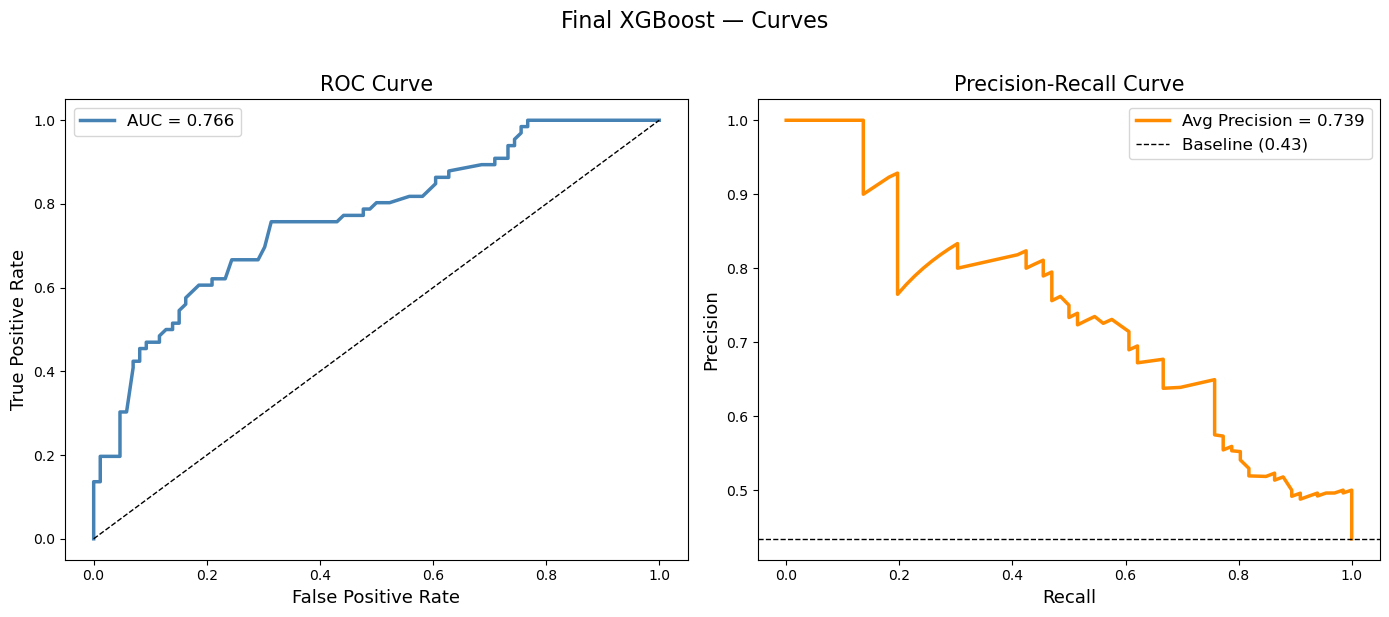

In [22]:
# Figure 1: ROC and Precision-Recall curves

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='steelblue', lw=2.5,
             label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=13)
axes[0].set_ylabel('True Positive Rate', fontsize=13)
axes[0].set_title('ROC Curve', fontsize=15)
axes[0].legend(fontsize=12)

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
axes[1].plot(rec, prec, color='darkorange', lw=2.5, label=f'Avg Precision = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Curve', fontsize=15)
axes[1].legend(fontsize=12)

plt.suptitle('Final XGBoost — Curves', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/final_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()


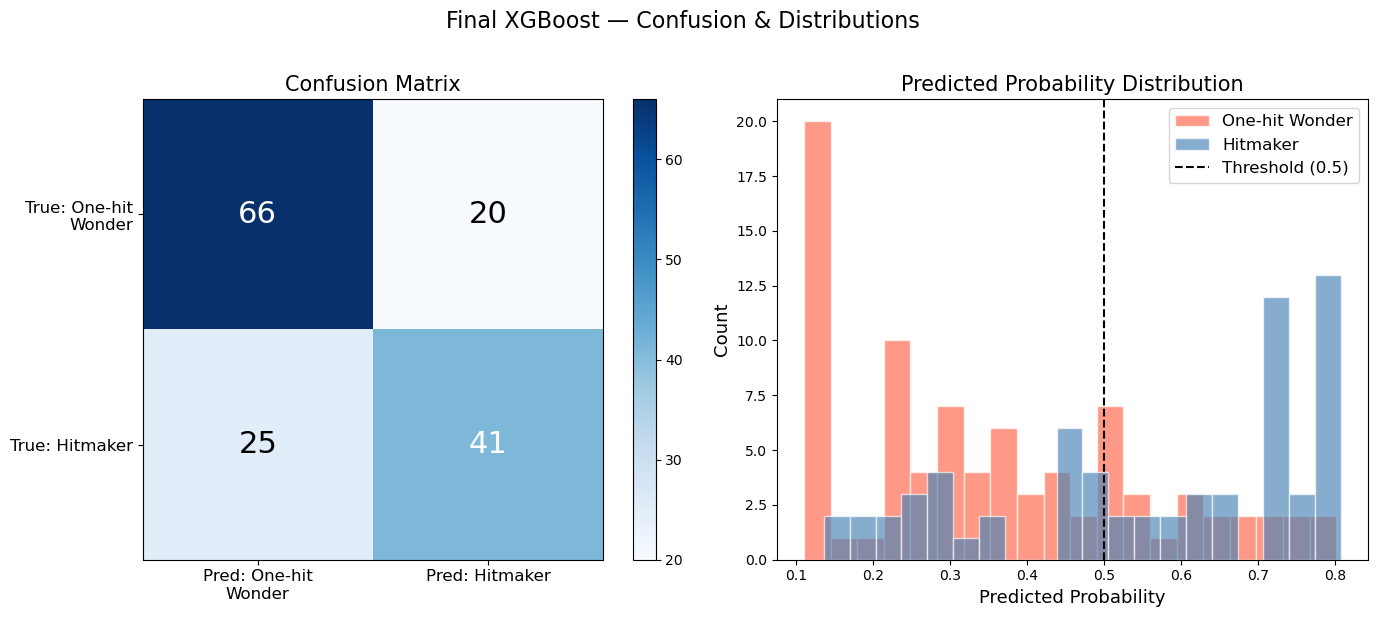

In [23]:
# Figure 2: Confusion matrix and predicted probability distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred: One-hit\nWonder', 'Pred: Hitmaker'], fontsize=12)
axes[0].set_yticklabels(['True: One-hit\nWonder', 'True: Hitmaker'], fontsize=12)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=22,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
axes[0].set_title('Confusion Matrix', fontsize=15)
plt.colorbar(im, ax=axes[0])

# Probability distribution
axes[1].hist(y_proba[y_test == 0], bins=20, alpha=0.65, color='tomato',
             label='One-hit Wonder', edgecolor='white')
axes[1].hist(y_proba[y_test == 1], bins=20, alpha=0.65, color='steelblue',
             label='Hitmaker', edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold (0.5)')
axes[1].set_xlabel('Predicted Probability', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Predicted Probability Distribution', fontsize=15)
axes[1].legend(fontsize=12)

plt.suptitle('Final XGBoost — Confusion & Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/final_confusion_dist.png',
            dpi=150, bbox_inches='tight')
plt.show()


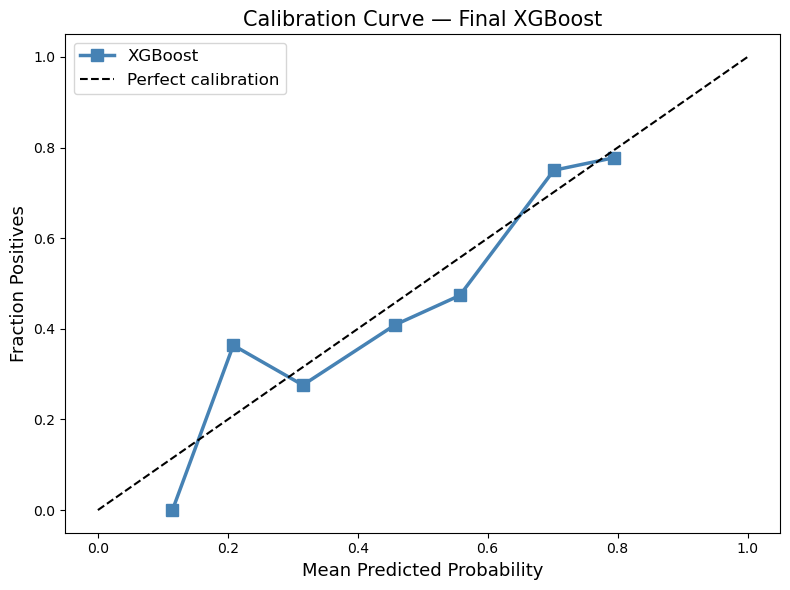

In [24]:
# Figure 3: Calibration curve

fig, ax = plt.subplots(figsize=(8, 6))
fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=8)
ax.plot(mean_pred, fraction_pos, 's-', color='steelblue', lw=2.5, markersize=8, label='XGBoost')
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability', fontsize=13)
ax.set_ylabel('Fraction Positives', fontsize=13)
ax.set_title('Calibration Curve — Final XGBoost', fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/final_calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()


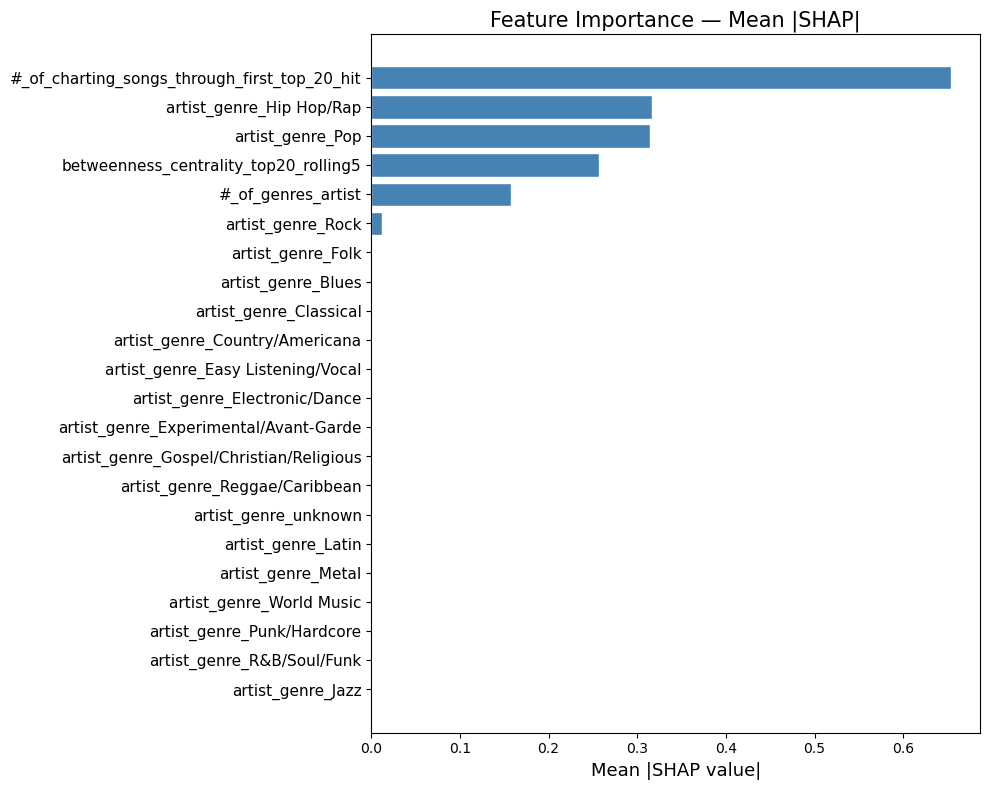

In [25]:
# Figure 4: SHAP mean absolute importance bar chart

explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_no_hc)

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test_no_hc.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|', fontsize=13)
ax.set_title('Feature Importance — Mean |SHAP|', fontsize=15)
ax.tick_params(axis='y', labelsize=11)
plt.tight_layout()
plt.savefig('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/final_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()


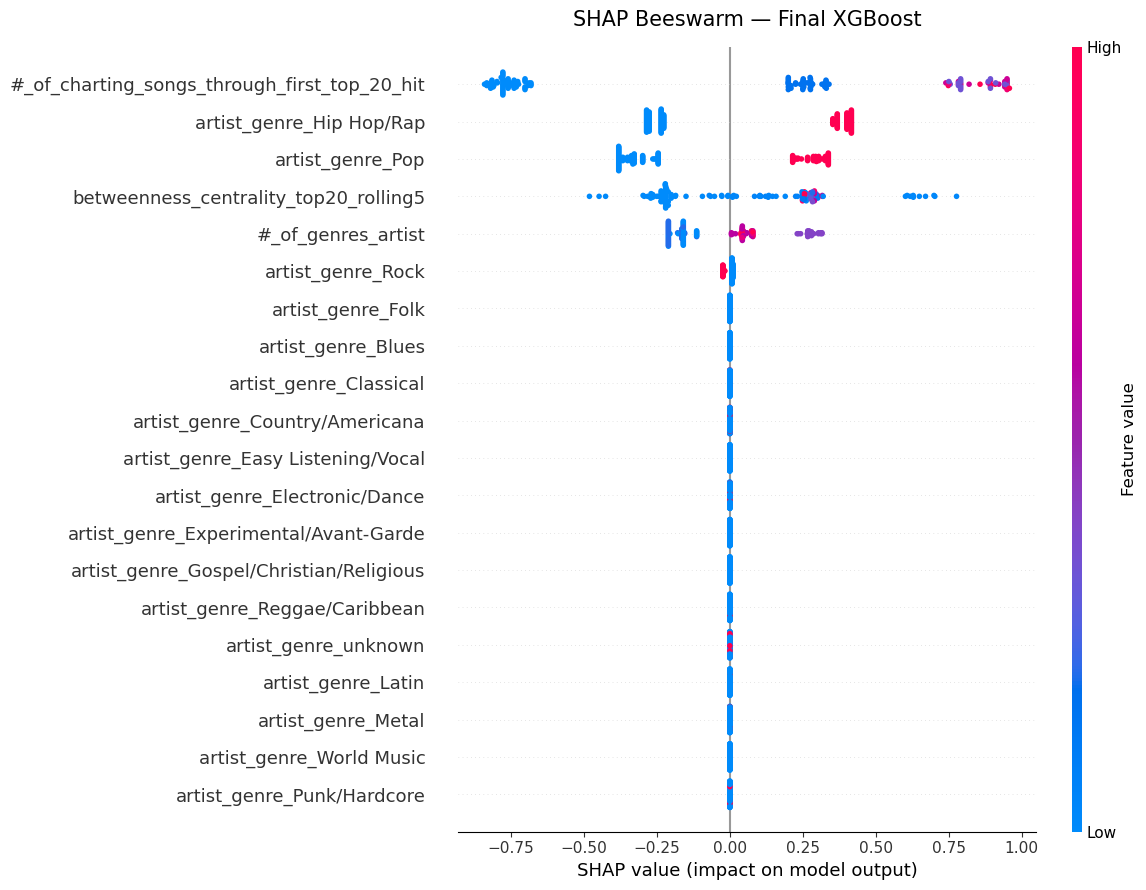

In [26]:
# Figure 5: SHAP beeswarm plot

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, X_test_no_hc, show=False, plot_size=None)
plt.title('SHAP Beeswarm — Final XGBoost', fontsize=15, pad=15)
plt.tight_layout()
plt.savefig('/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/final_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [27]:
# SHAP signed direction table — which direction each feature pushes prediction

shap_df      = pd.DataFrame(shap_values, columns=X_test_no_hc.columns)
direction_df = pd.DataFrame({
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'signed_corr':   [np.corrcoef(X_test_no_hc.iloc[:, i], shap_df.iloc[:, i])[0,1]
                      for i in range(X_test_no_hc.shape[1])]
}, index=X_test_no_hc.columns).sort_values('mean_abs_shap', ascending=False)

direction_df['direction'] = direction_df['signed_corr'].apply(
    lambda r: '+ (higher → Hitmaker)' if r > 0 else '- (higher → One-hit Wonder)'
)

print("\n── SHAP Feature Directions ──")
print(direction_df[['mean_abs_shap', 'signed_corr', 'direction']].to_string())



── SHAP Feature Directions ──
                                              mean_abs_shap  signed_corr                    direction
#_of_charting_songs_through_first_top_20_hit       0.653910     0.660435        + (higher → Hitmaker)
artist_genre_Hip Hop/Rap                           0.316825     0.997195        + (higher → Hitmaker)
artist_genre_Pop                                   0.314882     0.988566        + (higher → Hitmaker)
betweenness_centrality_top20_rolling5              0.256444     0.298426        + (higher → Hitmaker)
#_of_genres_artist                                 0.157146     0.523530        + (higher → Hitmaker)
artist_genre_Rock                                  0.011852    -0.995220  - (higher → One-hit Wonder)
artist_genre_Easy Listening/Vocal                  0.000000          NaN  - (higher → One-hit Wonder)
artist_genre_Electronic/Dance                      0.000000          NaN  - (higher → One-hit Wonder)
artist_genre_unknown                               

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
